In [ ]:
import pandas as pd
import glob
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
VegData = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTU6WAz3UfcApC4kZVCDhdYwU8FemgPqRv4DKM9QqAwoeD3xZbCSBRxCqgYlunKUw/pub?gid=787104991&single=true&output=csv')

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [ ]:
print(VegData.columns)

Index(['country', 'subnational1', 'subnational2', 'threshold', 'area_ha',
       'extent_2000_ha', 'extent_2010_ha', 'gain_2000-2020_ha',
       'tc_loss_ha_2001', 'tc_loss_ha_2002', 'tc_loss_ha_2003',
       'tc_loss_ha_2004', 'tc_loss_ha_2005', 'tc_loss_ha_2006',
       'tc_loss_ha_2007', 'tc_loss_ha_2008', 'tc_loss_ha_2009',
       'tc_loss_ha_2010', 'tc_loss_ha_2011', 'tc_loss_ha_2012',
       'tc_loss_ha_2013', 'tc_loss_ha_2014', 'tc_loss_ha_2015',
       'tc_loss_ha_2016', 'tc_loss_ha_2017', 'tc_loss_ha_2018',
       'tc_loss_ha_2019', 'tc_loss_ha_2020', 'tc_loss_ha_2021',
       'tc_loss_ha_2022', 'tc_loss_ha_2023'],
      dtype='object')


In [ ]:
path = "/content/drive/MyDrive/AQS Data/*.csv"
files = glob.glob(path)
df_list = [pd.read_csv(file) for file in files]
aqs_all = pd.concat(df_list, ignore_index=True)
print(aqs_all.shape)

/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in files]
/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in files]
/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in files]
/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in files]
/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(file) for file in files]
/tmp/ipykernel_1315/688403984.py:3: DtypeWarning: Columns (0) have 

(3129144, 55)


In [ ]:
print(aqs_all.columns)

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Metric Used', 'Method Name', 'Year',
       'Units of Measure', 'Event Type', 'Observation Count',
       'Observation Percent', 'Completeness Indicator', 'Valid Day Count',
       'Required Day Count', 'Exceptional Data Count', 'Null Data Count',
       'Primary Exceedance Count', 'Secondary Exceedance Count',
       'Certification Indicator', 'Num Obs Below MDL', 'Arithmetic Mean',
       'Arithmetic Standard Dev', '1st Max Value', '1st Max DateTime',
       '2nd Max Value', '2nd Max DateTime', '3rd Max Value',
       '3rd Max DateTime', '4th Max Value', '4th Max DateTime',
       '1st Max Non Overlapping Value', '1st NO Max DateTime',
       '2nd Max Non Overlapping Value', '2nd NO Max DateTime',
       '99th Percentile', '98th Percentile', '95th Percentile',
       '90th Percentile', '75th Percentile', '

In [ ]:
cols_keep = [
    "State Name", "County Name", "State Code", "County Code",
    "Year", "Parameter Name", "Pollutant Standard",
    "Arithmetic Mean", "Arithmetic Standard Dev",
    "1st Max Value", "1st Max DateTime",
    "2nd Max Value", "2nd Max DateTime",
    "3rd Max Value", "3rd Max DateTime",
    "4th Max Value", "4th Max DateTime"
]
cols_keep = [c for c in cols_keep if c in aqs_all.columns]
aqs_clean = aqs_all[cols_keep].copy()

numeric_cols = [
    "State Code", "County Code", "Year",
    "Arithmetic Mean", "Arithmetic Standard Dev",
    "1st Max Value", "2nd Max Value", "3rd Max Value", "4th Max Value"
]
for col in numeric_cols:
    if col in aqs_clean.columns:
        aqs_clean[col] = pd.to_numeric(aqs_clean[col], errors="coerce")

aqs_clean.to_csv('/content/drive/MyDrive/AQS Data/combined.csv', index=False)

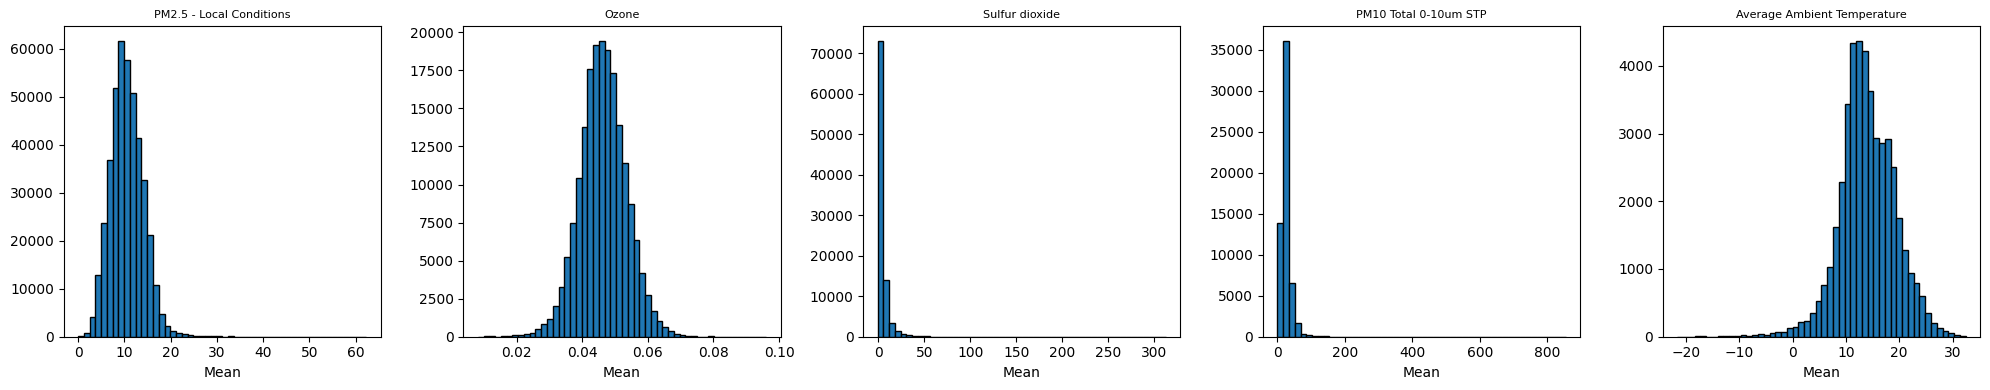

In [ ]:
# Distribution of Arithmetic Mean by pollutant
import matplotlib.pyplot as plt

top_params = aqs_clean['Parameter Name'].value_counts().head(5).index

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, param in zip(axes, top_params):
    subset = aqs_clean[aqs_clean['Parameter Name'] == param]['Arithmetic Mean'].dropna()
    ax.hist(subset, bins=50, edgecolor='black')
    ax.set_title(param, fontsize=8)
    ax.set_xlabel('Mean')
plt.tight_layout()
plt.show()

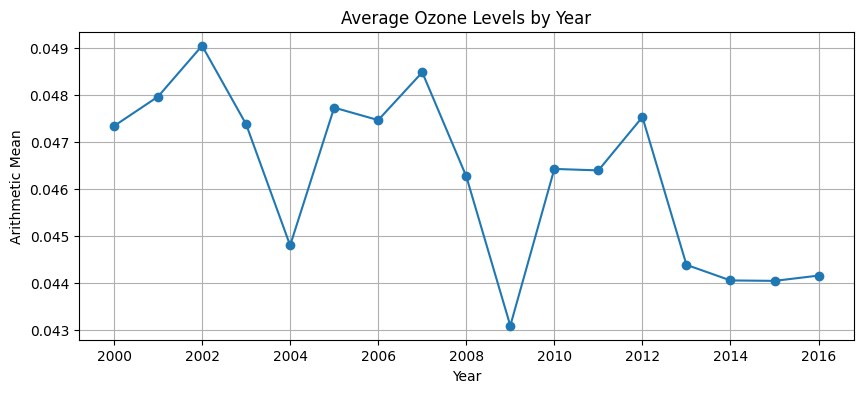

In [ ]:
#Average pollution by year (for a specific pollutant)
ozone = aqs_clean[aqs_clean['Parameter Name'] == 'Ozone']
yearly_avg = ozone.groupby('Year')['Arithmetic Mean'].mean()

plt.figure(figsize=(10, 4))
yearly_avg.plot(marker='o')
plt.title('Average Ozone Levels by Year')
plt.ylabel('Arithmetic Mean')
plt.xlabel('Year')
plt.grid(True)
plt.show()

In [ ]:
#Top 10 most polluted counties (by avg arithmetic mean, for ozone)
top_counties = (
    ozone.groupby(['State Name', 'County Name'])['Arithmetic Mean']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_counties)

State Name  County Name
Colorado    Clear Creek    0.061245
            Teller         0.058910
Utah        Weber          0.058440
California  Tulare         0.057934
Utah        Salt Lake      0.057869
            Utah           0.057179
Tennessee   Sevier         0.056942
Colorado    Douglas        0.056877
Utah        Davis          0.056753
Arizona     Gila           0.056481
Name: Arithmetic Mean, dtype: float64


In [ ]:
top_counties = (
    ozone.groupby(['State Name', 'County Name'])['Arithmetic Mean']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_counties)

State Name  County Name
Colorado    Clear Creek    0.061245
            Teller         0.058910
Utah        Weber          0.058440
California  Tulare         0.057934
Utah        Salt Lake      0.057869
            Utah           0.057179
Tennessee   Sevier         0.056942
Colorado    Douglas        0.056877
Utah        Davis          0.056753
Arizona     Gila           0.056481
Name: Arithmetic Mean, dtype: float64


In [ ]:
# SO2 and PM10 outliers, who are the worst offenders?
for param in ['Sulfur dioxide', 'PM10 Total 0-10um STP']:
    print(f"\n--- {param} ---")
    subset = aqs_clean[aqs_clean['Parameter Name'] == param]
    top = subset.groupby(['State Name', 'County Name'])['Arithmetic Mean'].mean().sort_values(ascending=False).head(5)
    print(top)


--- Sulfur dioxide ---
State Name     County Name
New York       Kings          23.853333
Hawaii         Hawaii         20.439897
Massachusetts  Middlesex      18.810865
New York       New York       13.886150
Arizona        Gila           12.582373
Name: Arithmetic Mean, dtype: float64

--- PM10 Total 0-10um STP ---
State Name         County Name          
Country Of Mexico  BAJA CALIFORNIA NORTE    82.726109
                   SONORA                   75.071737
                   CHIHUAHUA STATE          66.401798
Arizona            Santa Cruz               52.494942
                   Pinal                    51.033707
Name: Arithmetic Mean, dtype: float64


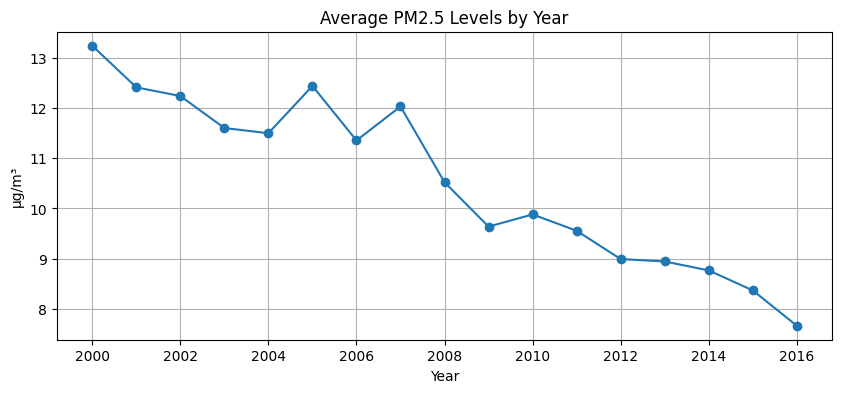

In [ ]:
#Trend over time for PM2.5
pm25 = aqs_clean[aqs_clean['Parameter Name'] == 'PM2.5 - Local Conditions']
yearly_pm25 = pm25.groupby('Year')['Arithmetic Mean'].mean()

plt.figure(figsize=(10,4))
yearly_pm25.plot(marker='o')
plt.title('Average PM2.5 Levels by Year')
plt.ylabel('µg/m³')
plt.xlabel('Year')
plt.grid(True)
plt.show()

In [ ]:
#Correlation between pollutants (pivot to wide format first)
pivot = aqs_clean.groupby(['State Name', 'County Name', 'Year', 'Parameter Name'])['Arithmetic Mean'].mean().unstack('Parameter Name')
print(pivot.corr()[['Ozone', 'PM2.5 - Local Conditions', 'Sulfur dioxide']].round(2))

Parameter Name                                   Ozone  \
Parameter Name                                           
1,1,1,2,2-Pentafluoroethane                       0.10   
1,1,1,2-Tetrachloroethane                        -0.16   
1,1,1-Trichloro-2,2-bis (p-chlorophenyl) ethane  -0.04   
1,1,2,2-Tetrachloroethane                        -0.01   
1,1,2-Trichloro-1,2,2-trifluoroethane             0.14   
...                                                ...   
trans-1,3-Dichloropropene                        -0.01   
trans-1,3-Dimethylcyclopentane                   -0.41   
trans-2-Butene                                    0.01   
trans-2-Hexene                                    0.03   
trans-2-Pentene                                  -0.02   

Parameter Name                                   PM2.5 - Local Conditions  \
Parameter Name                                                              
1,1,1,2,2-Pentafluoroethane                                          0.13   
1,1,1,2-Tetrac

Parameter Name            Carbon monoxide  Nitrogen dioxide (NO2)  Ozone  \
Parameter Name                                                             
Carbon monoxide                      1.00                    0.50  -0.02   
Nitrogen dioxide (NO2)               0.50                    1.00   0.12   
Ozone                               -0.02                    0.12   1.00   
PM10 Total 0-10um STP                0.24                    0.46   0.17   
PM2.5 - Local Conditions             0.20                    0.56   0.35   
Sulfur dioxide                       0.16                    0.45   0.23   

Parameter Name            PM10 Total 0-10um STP  PM2.5 - Local Conditions  \
Parameter Name                                                              
Carbon monoxide                            0.24                      0.20   
Nitrogen dioxide (NO2)                     0.46                      0.56   
Ozone                                      0.17                      0.35   
PM10 T

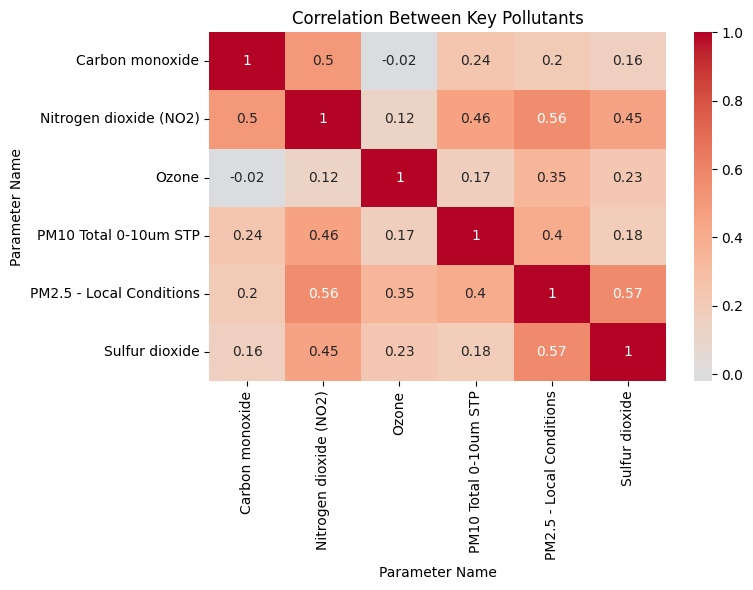

In [ ]:
# Correlation matrix
key_params = [
    'Ozone', 'PM2.5 - Local Conditions', 'Sulfur dioxide',
    'PM10 Total 0-10um STP', 'Nitrogen dioxide (NO2)',
    'Carbon monoxide', 'Lead'
]

pivot_key = aqs_clean[aqs_clean['Parameter Name'].isin(key_params)] \
    .groupby(['State Name', 'County Name', 'Year', 'Parameter Name'])['Arithmetic Mean'] \
    .mean().unstack('Parameter Name')

corr = pivot_key.corr().round(2)
print(corr)

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Key Pollutants')
plt.tight_layout()plt.show()